In this notebook I want to study $dg$-algebras. The main example will be the Koszul DG algebra $A=\mathbb{F}_p[x_1,\ldots,x_n]/(x_1^q,\ldots,x_n^q)\otimes \Lambda(\theta_1,\ldots,\theta_n)$. With the expected differential $d(x_i)=0$ and $d(\theta_i)=x_i$.

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from torch.utils.data import TensorDataset, DataLoader, random_split
import itertools

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cpu


In [8]:
class DGModel(nn.Module):
    def __init__(self, D, p, emb_dim=128, hid_dim=512, n_ops=2):
        super().__init__()

        self.elem_emb = nn.Embedding(D + 1, emb_dim)  # +1 for dummy
        self.op_emb = nn.Embedding(n_ops, emb_dim)

        self.net = nn.Sequential(
            nn.Linear(3 * emb_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, D * p),
        )

        self.D = D
        self.p = p

    def forward(self, op, left, right):
        op_e = self.op_emb(op)
        left_e = self.elem_emb(left)
        right_e = self.elem_emb(right)

        h = torch.cat([op_e, left_e, right_e], dim=-1)
        out = self.net(h)

        return out.view(-1, self.D, self.p)

I will do this for $p=5,\ q=5,\ n=2$.

In [24]:
#because there is no canonical way of identifying the order of elements, build the explicit indexing, where each basis element is a tuple with 
#the first two powers being the bosonic ones and the last two the fermionic
def build_basis_tensor(q=5, device="cpu"):
    vals = torch.cartesian_prod(
        torch.arange(q, device=device),
        torch.arange(q, device=device),
        torch.arange(2, device=device),
        torch.arange(2, device=device),
    )
    # columns: a1, a2, e1, e2
    return vals.long()

def basis_index_tensor(a1, a2, e1, e2, q):
    return (((a1 * q + a2) * 2 + e1) * 2 + e2).long()



def build_mul_targets_tensor(basis, p=5, q=5):
    device = basis.device
    D = basis.shape[0]

    left = basis[:, None, :]   # [D, 1, 4]
    right = basis[None, :, :]  # [1, D, 4]

    a1 = left[..., 0] #[D,1]
    a2 = left[..., 1] #[D,1]
    e1 = left[..., 2] #[D,1]
    e2 = left[..., 3] #[D,1]

    b1 = right[..., 0] #[1,D]
    b2 = right[..., 1] #[1,D]
    f1 = right[..., 2] #[1,D]
    f2 = right[..., 3] #[1,D]

    c1 = a1 + b1 #[D,D]
    c2 = a2 + b2 #[D,D]

    g1 = e1 + f1 #[D,D]
    g2 = e2 + f2 #[D,D]

    valid = (c1 < q) & (c2 < q) & (g1 < 2) & (g2 < 2) #[D,D]; basically here are the non-zero basis elements

    # exterior sign: theta2 from left crossing theta1 from right
    inversions = e2 * f1 #[D,D]
    coeff = torch.ones_like(c1)
    coeff[inversions % 2 == 1] = p - 1

    out_idx = basis_index_tensor(c1.clamp(max=q-1), c2.clamp(max=q-1), g1.clamp(max=1), g2.clamp(max=1), q) #[D,D]; for each combination of elements return the index of the product

    targets = torch.zeros(D, D, D, dtype=torch.long, device=device)

    ii, jj = torch.where(valid) #this is a boolean [D,D] where the True values are for pairs whose product is non-zero
    targets[ii, jj, out_idx[ii, jj]] = coeff[ii, jj] % p

    return targets

def build_diff_targets_tensor(basis, p=5, q=5):
    device = basis.device
    D = basis.shape[0]

    a1 = basis[:, 0] #[D]
    a2 = basis[:, 1]
    e1 = basis[:, 2]
    e2 = basis[:, 3]

    targets = torch.zeros(D, D, dtype=torch.long, device=device)

    # theta1 term: d(theta1)=x1
    mask1 = (e1 == 1) & (a1 + 1 < q) #[D]; flag all entries where there is a theta1 and x1 does not vanish after applying differential
    c1 = a1 + 1
    c2 = a2
    idx1 = basis_index_tensor(c1.clamp(max=q-1), c2, torch.zeros_like(e1), e2, q)

    rows1 = torch.where(mask1)[0] #returns an array of positions where the mask is true
    targets[rows1, idx1[rows1]] = (targets[rows1, idx1[rows1]] + 1) % p

    # theta2 term: d(theta2)=x2, with sign (-1)^e1
    mask2 = (e2 == 1) & (a2 + 1 < q)
    c1 = a1
    c2 = a2 + 1
    idx2 = basis_index_tensor(c1, c2.clamp(max=q-1), e1, torch.zeros_like(e2), q)

    sign2 = torch.where(
        e1 == 1,
        torch.full_like(e1, p - 1),
        torch.ones_like(e1),
    )

    rows2 = torch.where(mask2)[0]
    targets[rows2, idx2[rows2]] = (targets[rows2, idx2[rows2]] + sign2[rows2]) % p

    return targets

In [25]:
from torch.utils.data import TensorDataset, DataLoader, random_split

def build_dg_dataset_tensor(p=5, q=5, frac=0.4, batch_size=None, seed=0, device="cpu", diff_repeat=1):
    basis = build_basis_tensor(q=q, device=device)
    D = basis.shape[0]
    dummy = D

    mul_targets = build_mul_targets_tensor(basis, p=p, q=q)   # [D, D, D]
    diff_targets = build_diff_targets_tensor(basis, p=p, q=q) # [D, D]

    # multiplication examples
    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    ) #[D^2,2]
    mul_ops = torch.zeros(D * D, dtype=torch.long, device=device)
    mul_left = pairs[:, 0]
    mul_right = pairs[:, 1]
    mul_y = mul_targets[mul_left, mul_right]

    # differential examples
    diff_left_base = torch.arange(D, device=device)
    diff_ops_base = torch.ones(D, dtype=torch.long, device=device)
    diff_right_base = torch.full((D,), dummy, dtype=torch.long, device=device)
    diff_y_base = diff_targets

    if diff_repeat > 1:
        diff_ops = diff_ops_base.repeat(diff_repeat)
        diff_left = diff_left_base.repeat(diff_repeat)
        diff_right = diff_right_base.repeat(diff_repeat)
        diff_y = diff_y_base.repeat(diff_repeat, 1)
    else:
        diff_ops = diff_ops_base
        diff_left = diff_left_base
        diff_right = diff_right_base
        diff_y = diff_y_base

    ops = torch.cat([mul_ops, diff_ops], dim=0)
    lefts = torch.cat([mul_left, diff_left], dim=0)
    rights = torch.cat([mul_right, diff_right], dim=0)
    targets = torch.cat([mul_y, diff_y], dim=0)

    dataset = TensorDataset(ops.cpu(), lefts.cpu(), rights.cpu(), targets.cpu())

    n = len(dataset)
    n_train = int(frac * n)
    n_test = n - n_train

    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = random_split(dataset, [n_train, n_test], generator=gen)

    if batch_size is None:
        train_batch_size = n_train
        test_batch_size = n_test
    else:
        train_batch_size = batch_size
        test_batch_size = batch_size

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    return {
        "basis": basis.cpu(),
        "D": D,
        "dummy": dummy,
        "mul_targets": mul_targets.cpu(),
        "diff_targets": diff_targets.cpu(),
        "train_loader": train_loader,
        "test_loader": test_loader,
        "dataset": dataset,
    }

In [42]:
def coeff_accuracy(logits, targets):
    """
    logits:  [batch, D, p]
    targets: [batch, D]
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).float().mean()


def vector_exact_accuracy(logits, targets):
    """
    Exact vector accuracy: entire coefficient vector must match.
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).all(dim=1).float().mean()


@torch.no_grad()
def evaluate_dg(model, loader, p, device):
    model.eval()

    total_loss = 0.0
    total_n = 0

    total_coeff_acc = 0.0
    total_exact_acc = 0.0

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)

        loss = F.cross_entropy(
            logits.reshape(-1, p),
            target.reshape(-1),
        )

        batch_n = op.shape[0]
        total_loss += loss.item() * batch_n
        total_n += batch_n

        total_coeff_acc += coeff_accuracy(logits, target).item() * batch_n
        total_exact_acc += vector_exact_accuracy(logits, target).item() * batch_n

    return {
        "loss": total_loss / total_n,
        "coeff_acc": total_coeff_acc / total_n,
        "exact_acc": total_exact_acc / total_n,
    }

@torch.no_grad()
def evaluate_dg_by_task(model, loader, p, device):
    model.eval()

    stats = {
        "mul":  {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
        "diff": {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
    }

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)  # [batch, D, p]
        pred = logits.argmax(dim=-1)     # [batch, D]

        for op_value, name in [(0, "mul"), (1, "diff")]:
            mask = (op == op_value)

            if mask.sum() == 0:
                continue

            logits_t = logits[mask]
            target_t = target[mask]
            pred_t = pred[mask]

            loss_t = F.cross_entropy(
                logits_t.reshape(-1, p),
                target_t.reshape(-1),
            )

            coeff_acc_t = (pred_t == target_t).float().mean()
            exact_acc_t = (pred_t == target_t).all(dim=1).float().mean()

            n_t = mask.sum().item()

            stats[name]["n"] += n_t
            stats[name]["loss_sum"] += loss_t.item() * n_t
            stats[name]["coeff_sum"] += coeff_acc_t.item() * n_t
            stats[name]["exact_sum"] += exact_acc_t.item() * n_t

    out = {}

    for name in ["mul", "diff"]:
        n = stats[name]["n"]

        if n == 0:
            out[f"{name}_loss"] = float("nan")
            out[f"{name}_coeff_acc"] = float("nan")
            out[f"{name}_exact_acc"] = float("nan")
        else:
            out[f"{name}_loss"] = stats[name]["loss_sum"] / n
            out[f"{name}_coeff_acc"] = stats[name]["coeff_sum"] / n
            out[f"{name}_exact_acc"] = stats[name]["exact_sum"] / n

    return out

def train_dg(
    p=5,
    q=5,
    frac=0.6,
    batch_size=256,
    emb_dim=128,
    hid_dim=1000,
    lr=1e-3,
    weight_decay=1e-2,
    n_epochs=600,
    seed=0,
    device="cpu",
):
    data = build_dg_dataset_tensor(
    p=p,
    q=q,
    frac=frac,
    batch_size=batch_size,
    seed=seed,
    device="cpu",
    diff_repeat=100,  # optional but recommended
)
    D = data["D"]

    model = DGModel(
        D=D,
        p=p,
        emb_dim=emb_dim,
        hid_dim=hid_dim,
        n_ops=2,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {
    "train_mul_loss": [],
    "test_mul_loss": [],
    "train_mul_coeff_acc": [],
    "test_mul_coeff_acc": [],
    "train_mul_exact_acc": [],
    "test_mul_exact_acc": [],

    "train_diff_loss": [],
    "test_diff_loss": [],
    "train_diff_coeff_acc": [],
    "test_diff_coeff_acc": [],
    "train_diff_exact_acc": [],
    "test_diff_exact_acc": [],
}

    for epoch in range(n_epochs):
        model.train()

        for op, left, right, target in data["train_loader"]:
            op = op.to(device)
            left = left.to(device)
            right = right.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            logits = model(op, left, right)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )

            loss.backward()
            optimizer.step()

        if (epoch + 1) % 100 == 0 or epoch == 0:
            train_metrics = evaluate_dg_by_task(model, data["train_loader"], p, device)
            test_metrics = evaluate_dg_by_task(model, data["test_loader"], p, device)

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            history["train_diff_loss"].append(train_metrics["diff_loss"])
            history["test_diff_loss"].append(test_metrics["diff_loss"])
            history["train_diff_coeff_acc"].append(train_metrics["diff_coeff_acc"])
            history["test_diff_coeff_acc"].append(test_metrics["diff_coeff_acc"])
            history["train_diff_exact_acc"].append(train_metrics["diff_exact_acc"])
            history["test_diff_exact_acc"].append(test_metrics["diff_exact_acc"])

            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_diff_loss={train_metrics['diff_loss']:.4f} | "
                f"test_diff_loss={test_metrics['diff_loss']:.4f} | "
                f"mul_train={train_metrics['mul_exact_acc']:.4f} | "
                f"mul_test={test_metrics['mul_exact_acc']:.4f} | "
                f"diff_train={train_metrics['diff_exact_acc']:.4f} | "
                f"diff_test={test_metrics['diff_exact_acc']:.4f}"
            )

    return model, data, history

In [43]:
md, data, hist=train_dg(batch_size=None,n_epochs=2000,device=device)

epoch=     1 | train_mul_loss=1.2543 | test_mul_loss=1.2549 | train_diff_loss=1.2375 | test_diff_loss=1.2378 | mul_train=0.0142 | mul_test=0.0109 | diff_train=0.0000 | diff_test=0.0000
epoch=   100 | train_mul_loss=0.0135 | test_mul_loss=0.0144 | train_diff_loss=0.0139 | test_diff_loss=0.0143 | mul_train=0.7976 | mul_test=0.7974 | diff_train=0.4944 | diff_test=0.4835
epoch=   200 | train_mul_loss=0.0113 | test_mul_loss=0.0131 | train_diff_loss=0.0003 | test_diff_loss=0.0003 | mul_train=0.7976 | mul_test=0.7974 | diff_train=1.0000 | diff_test=1.0000
epoch=   300 | train_mul_loss=0.0071 | test_mul_loss=0.0115 | train_diff_loss=0.0001 | test_diff_loss=0.0001 | mul_train=0.7977 | mul_test=0.7974 | diff_train=1.0000 | diff_test=1.0000
epoch=   400 | train_mul_loss=0.0032 | test_mul_loss=0.0132 | train_diff_loss=0.0000 | test_diff_loss=0.0000 | mul_train=0.8528 | mul_test=0.7972 | diff_train=1.0000 | diff_test=1.0000
epoch=   500 | train_mul_loss=0.0011 | test_mul_loss=0.0183 | train_diff_lo

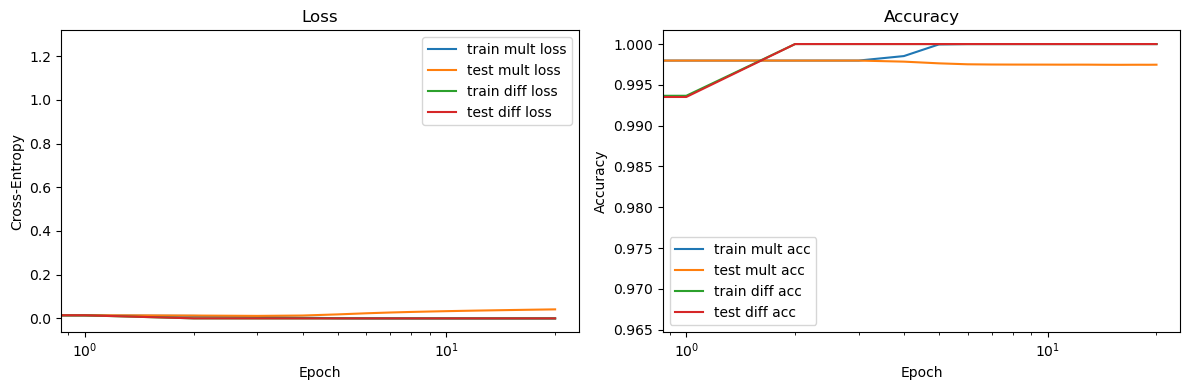

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs=torch.arange(len(hist['train_mul_loss'])).cpu()

axes[0].set_xscale('log')
axes[0].plot(epochs, hist['train_mul_loss'], label="train mult loss")
axes[0].plot(epochs, hist['test_mul_loss'], label="test mult loss")
axes[0].plot(epochs, hist['train_diff_loss'], label="train diff loss")
axes[0].plot(epochs, hist['test_diff_loss'], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].set_xscale('log')
axes[1].plot(epochs, hist['train_mul_coeff_acc'], label="train mult acc")
axes[1].plot(epochs, hist['test_mul_coeff_acc'], label="test mult acc")
axes[1].plot(epochs, hist['train_diff_coeff_acc'], label="train diff acc")
axes[1].plot(epochs, hist['test_diff_coeff_acc'], label="test diff acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
